# 🔧 Day 25: GPU FinOps & Cost Optimization - Hands-on Lab

This notebook connects to a local Docker Compose cluster (via ngrok/cloudflared tunnel) to demonstrate:
1. **GPU Cluster Monitoring** - Real-time GPU metrics
2. **Cost Tracking (OpenCost-like)** - Per-node cost allocation & waste analysis
3. **Spot Instance Management** - Bidding, preemption, savings
4. **Autoscaling (KEDA-like)** - Policy-based GPU scaling
5. **Budget Management & Forecasting** - Alerts, burn rate

## Prerequisites
- Docker Compose running locally with the GPU FinOps Lab services
- Tunnel exposed via ngrok or cloudflared (free tier)

In [1]:
# Cell 1: Setup
!pip install -q requests pandas matplotlib plotly

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from IPython.display import display, HTML, clear_output

In [2]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lê Minh Hoàng"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600101"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [3]:
# Cell 2: Configure Gateway URL
# Replace with your ngrok/cloudflared URL after running the tunnel
GATEWAY_URL = "https://notification-starsmerchant-uncle-vatican.trycloudflare.com"  # <-- CHANGE THIS

# Test connection
try:
    r = requests.get(f"{GATEWAY_URL}/", timeout=10)
    print("✅ Connected to GPU FinOps Lab Gateway")
    print(json.dumps(r.json(), indent=2))
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Make sure Docker Compose is running and tunnel is active")

✅ Connected to GPU FinOps Lab Gateway
{
  "service": "GPU FinOps Lab Gateway",
  "endpoints": {
    "cluster": "/cluster/*",
    "billing": "/billing/*",
    "spot": "/spot/*",
    "autoscaler": "/autoscaler/*",
    "cost": "/cost/*"
  }
}


---
## Part 1: GPU Cluster Monitoring
Observe the mock GPU cluster state — nodes, utilization, memory, power draw.

In [4]:
# Cell 3: View Cluster Nodes
nodes = requests.get(f"{GATEWAY_URL}/cluster/nodes").json()

print(f"📊 Cluster has {len(nodes)} nodes")
print("=" * 60)

for node_id, gpus in nodes.items():
    print(f"\n🖥️  {node_id}:")
    for gpu in gpus:
        status_icon = "🟢" if gpu['status'] == 'idle' else "🔴"
        print(f"   GPU {gpu['gpu_id']} [{gpu['gpu_type']}] {status_icon} "
              f"Util: {gpu['utilization']:.1f}% | "
              f"Mem: {gpu['memory_used_gb']:.1f}/{gpu['memory_total_gb']}GB | "
              f"Power: {gpu['power_draw_watts']:.0f}W | "
              f"Temp: {gpu['temperature_c']:.0f}°C")

📊 Cluster has 4 nodes

🖥️  node-00:
   GPU 0 [T4] 🟢 Util: 4.0% | Mem: 1.5/16.0GB | Power: 46W | Temp: 32°C
   GPU 1 [T4] 🟢 Util: 9.3% | Mem: 1.6/16.0GB | Power: 22W | Temp: 38°C

🖥️  node-01:
   GPU 0 [A100] 🟢 Util: 5.3% | Mem: 1.9/80.0GB | Power: 35W | Temp: 43°C
   GPU 1 [A100] 🟢 Util: 4.0% | Mem: 0.9/80.0GB | Power: 44W | Temp: 45°C

🖥️  node-02:
   GPU 0 [V100] 🟢 Util: 1.1% | Mem: 1.4/32.0GB | Power: 48W | Temp: 37°C
   GPU 1 [V100] 🟢 Util: 13.3% | Mem: 1.2/32.0GB | Power: 38W | Temp: 33°C

🖥️  node-03:
   GPU 0 [T4] 🟢 Util: 12.8% | Mem: 1.9/16.0GB | Power: 41W | Temp: 39°C
   GPU 1 [T4] 🟢 Util: 4.3% | Mem: 1.9/16.0GB | Power: 36W | Temp: 33°C


In [5]:
# Cell 4: Cluster Metrics Summary
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()

print("📈 Cluster Metrics")
print("=" * 40)
print(f"Total GPUs:          {metrics['total_gpus']}")
print(f"Busy GPUs:           {metrics['busy_gpus']}")
print(f"Idle GPUs:           {metrics['idle_gpus']}")
print(f"Avg Utilization:     {metrics['avg_utilization']:.1f}%")
print(f"Memory Used:         {metrics['total_memory_used_gb']:.1f} GB")
print(f"Memory Capacity:     {metrics['total_memory_capacity_gb']:.1f} GB")
print(f"Total Power Draw:    {metrics['total_power_draw_watts']:.0f} W")
print(f"Node Count:          {metrics['node_count']}")

📈 Cluster Metrics
Total GPUs:          8
Busy GPUs:           0
Idle GPUs:           8
Avg Utilization:     6.8%
Memory Used:         12.3 GB
Memory Capacity:     288.0 GB
Total Power Draw:    310 W
Node Count:          4


---
## Part 2: Workload Submission & Cost Tracking
Submit GPU workloads and track their costs in real-time.

In [6]:
# Cell 5: Submit multiple workloads
workloads = [
    {"workload_id": "train-resnet-001", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 300},
    {"workload_id": "train-bert-002", "gpu_type_preferred": "A100", "gpu_count": 1, "duration_seconds": 600},
    {"workload_id": "inference-api-003", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 120},
    {"workload_id": "train-llm-004", "gpu_type_preferred": "A100", "gpu_count": 2, "duration_seconds": 900},
]

print("🚀 Submitting workloads...")
for wl in workloads:
    r = requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json=wl)
    result = r.json()
    print(f"   {wl['workload_id']}: {result['status']} → {result.get('assigned', 'queued')}")

# Check cluster state after submission
print("\n📊 Updated metrics:")
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   Busy GPUs: {metrics['busy_gpus']}/{metrics['total_gpus']} | Utilization: {metrics['avg_utilization']:.1f}%")

🚀 Submitting workloads...
   train-resnet-001: running → [{'node_id': 'node-00', 'gpu_id': 0}]
   train-bert-002: running → [{'node_id': 'node-01', 'gpu_id': 0}]
   inference-api-003: running → [{'node_id': 'node-00', 'gpu_id': 1}]
   train-llm-004: running → [{'node_id': 'node-01', 'gpu_id': 1}, {'node_id': 'node-02', 'gpu_id': 0}]

📊 Updated metrics:
   Busy GPUs: 5/8 | Utilization: 53.1%


In [7]:
# Cell 6: Record billing for workloads
billing_events = [
    {"workload_id": "train-resnet-001", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 300, "is_spot": False},
    {"workload_id": "train-bert-002", "gpu_type": "A100", "gpu_count": 1, "duration_seconds": 600, "is_spot": False},
    {"workload_id": "inference-api-003", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 120, "is_spot": True},
    {"workload_id": "train-llm-004", "gpu_type": "A100", "gpu_count": 2, "duration_seconds": 900, "is_spot": True},
]

print("💰 Recording billing events...")
for event in billing_events:
    r = requests.post(f"{GATEWAY_URL}/billing/record", json=event)
    result = r.json()
    spot_label = "[SPOT]" if event['is_spot'] else "[ON-DEMAND]"
    print(f"   {event['workload_id']} {spot_label}: ${result['total_cost_usd']:.4f} "
          f"(saved ${result['savings_usd']:.4f})")

# Get billing summary
print("\n📋 Billing Summary:")
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total Cost:     ${summary['total_cost_usd']:.4f}")
print(f"   Total Savings:  ${summary['total_savings_usd']:.4f}")
print(f"   Budget Used:    {summary['budget_utilization_pct']:.1f}%")
print(f"   Alert Status:   {summary['alert']}")

💰 Recording billing events...
   train-resnet-001 [ON-DEMAND]: $0.0292 (saved $0.0000)
   train-bert-002 [ON-DEMAND]: $0.6117 (saved $0.0000)
   inference-api-003 [SPOT]: $0.0035 (saved $0.0082)
   train-llm-004 [SPOT]: $0.5505 (saved $1.2845)

📋 Billing Summary:
   Total Cost:     $1.1949
   Total Savings:  $1.2927
   Budget Used:    1.2%
   Alert Status:   OK


---
## Part 3: Spot Instance Management
Demonstrate spot bidding, preemption handling, and cost savings.

In [8]:
# Cell 7: Check spot pricing
spot_pricing = requests.get(f"{GATEWAY_URL}/spot/pricing").json()

print("💹 Current Spot Pricing")
print("=" * 60)
print(f"{'GPU Type':<10} {'On-Demand':<12} {'Spot Price':<12} {'Discount':<10} {'Availability'}")
print("-" * 60)
for gpu, info in spot_pricing.items():
    print(f"{gpu:<10} ${info['on_demand_price']:<10.2f} ${info['current_spot_price']:<10.4f} "
          f"{info['discount_pct']:<8.1f}% {info['availability']}")

💹 Current Spot Pricing
GPU Type   On-Demand    Spot Price   Discount   Availability
------------------------------------------------------------
T4         $0.35       $0.2551     27.1    % medium
A100       $3.67       $2.0981     42.8    % medium
V100       $2.48       $1.8621     24.9    % low


In [9]:
# Cell 8: Request spot instances
spot_requests = [
    {"instance_id": "spot-t4-001", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": "batch-job-1"},
    {"instance_id": "spot-t4-002", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.12, "workload_id": "batch-job-2"},
    {"instance_id": "spot-a100-001", "gpu_type": "A100", "gpu_count": 1, "max_price_per_hour": 1.50, "workload_id": "training-3"},
]

print("🎯 Requesting Spot Instances...")
for req in spot_requests:
    r = requests.post(f"{GATEWAY_URL}/spot/request", json=req)
    result = r.json()
    status_icon = "✅" if result['status'] == 'granted' else "❌"
    print(f"   {status_icon} {req['instance_id']} ({req['gpu_type']}): {result['status']}")
    if result['status'] == 'rejected':
        print(f"      Reason: {result.get('reason', 'N/A')}")

🎯 Requesting Spot Instances...
   ✅ spot-t4-001 (T4): granted
   ✅ spot-t4-002 (T4): granted
   ✅ spot-a100-001 (A100): granted


In [10]:
# Cell 9: Simulate spot preemption
print("⚡ Simulating spot preemption event...")
preemption = requests.post(f"{GATEWAY_URL}/spot/simulate-preemption").json()

print(f"\n   Preempted instances: {preemption['preempted_count']}")
print(f"   Still active: {preemption['total_active']}")

if preemption['preempted_instances']:
    print("\n   ⚠️  Preempted:")
    for p in preemption['preempted_instances']:
        print(f"      - {p['instance_id']} (ran for {p['runtime_seconds']:.0f}s, "
              f"{p['notice_seconds']}s warning)")

# Savings report
print("\n💰 Spot Savings Report:")
savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot cost:        ${savings['total_spot_cost']:.4f}")
print(f"   On-demand equiv:  ${savings['on_demand_equivalent']:.4f}")
print(f"   Total saved:      ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

⚡ Simulating spot preemption event...

   Preempted instances: 0
   Still active: 3

💰 Spot Savings Report:
   Spot cost:        $0.0013
   On-demand equiv:  $0.0042
   Total saved:      $0.0029 (70.0%)


---
## Part 4: Autoscaling (KEDA-like)
Configure and trigger GPU autoscaling based on utilization thresholds.

In [11]:
# Cell 10: View and update autoscaling policy
policy = requests.get(f"{GATEWAY_URL}/autoscaler/policy").json()
print("📜 Current Autoscaling Policy:")
for k, v in policy.items():
    print(f"   {k}: {v}")

# Update policy - more aggressive scaling
new_policy = {
    "scale_up_threshold": 70,
    "scale_down_threshold": 25,
    "cooldown_seconds": 30,
    "max_nodes": 10,
    "min_nodes": 2,
    "preferred_gpu_type": "T4",
    "cost_aware": True
}

print("\n🔄 Updating policy...")
updated = requests.post(f"{GATEWAY_URL}/autoscaler/policy", json=new_policy).json()
print("   ✅ Policy updated")

📜 Current Autoscaling Policy:
   scale_up_threshold: 80.0
   scale_down_threshold: 20.0
   cooldown_seconds: 60
   max_nodes: 8
   min_nodes: 1
   preferred_gpu_type: T4
   cost_aware: True

🔄 Updating policy...
   ✅ Policy updated


In [12]:
# Cell 11: Trigger autoscaler evaluation
print("🔄 Evaluating autoscaling decision...")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()

action_icons = {"scale_up": "⬆️", "scale_down": "⬇️", "no_action": "➡️"}
print(f"\n   {action_icons.get(decision['action'], '❓')} Action: {decision['action'].upper()}")
print(f"   Reason: {decision['reason']}")
print(f"   Current utilization: {decision['current_utilization']:.1f}%")
print(f"   Nodes: {decision['node_count']} → {decision['target_node_count']}")

# Run multiple evaluations to show scaling behavior
print("\n📊 Running 5 evaluation cycles...")
for i in range(5):
    time.sleep(2)
    d = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
    print(f"   Cycle {i+1}: {d['action']:<12} | Util: {d['current_utilization']:.1f}% | Nodes: {d['node_count']}→{d['target_node_count']}")

🔄 Evaluating autoscaling decision...

   ➡️ Action: NO_ACTION
   Reason: Utilization 53.1% within thresholds [25.0-70.0%]
   Current utilization: 53.1%
   Nodes: 4 → 4

📊 Running 5 evaluation cycles...
   Cycle 1: no_action    | Util: 53.1% | Nodes: 4→4
   Cycle 2: no_action    | Util: 53.1% | Nodes: 4→4
   Cycle 3: no_action    | Util: 53.1% | Nodes: 4→4
   Cycle 4: no_action    | Util: 53.1% | Nodes: 4→4
   Cycle 5: no_action    | Util: 53.1% | Nodes: 4→4


---
## Part 5: Cost Analysis & Optimization (OpenCost-like)
Analyze cost allocation, identify waste, and get recommendations.

In [13]:
# Cell 12: Take cost snapshots
print("📸 Taking cost snapshots...")
snapshots = []
for i in range(5):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    snapshots.append(snap)
    print(f"   Snapshot {i+1}: Total=${snap['total_cost_usd']:.6f} | "
          f"Idle=${snap['total_idle_cost_usd']:.6f} | "
          f"Waste={snap['waste_pct']:.1f}%")
    time.sleep(1)

📸 Taking cost snapshots...
   Snapshot 1: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 2: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 3: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 4: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 5: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%


In [14]:
# Cell 13: Waste Report
waste = requests.get(f"{GATEWAY_URL}/cost/waste-report").json()

print("🗑️  WASTE ANALYSIS REPORT")
print("=" * 50)
print(f"   Average Waste:          {waste.get('avg_waste_pct', 0):.1f}%")
print(f"   Total Idle Cost:        ${waste.get('total_idle_cost_usd', 0):.6f}")
print(f"   Total Cost:             ${waste.get('total_cost_usd', 0):.6f}")
print(f"   Potential Monthly Save:  ${waste.get('potential_monthly_savings', 0):.2f}")
print(f"   Severity:               {waste.get('severity', 'N/A')}")

🗑️  WASTE ANALYSIS REPORT
   Average Waste:          23.2%
   Total Idle Cost:        $0.044165
   Total Cost:             $0.190280
   Potential Monthly Save:  $2289.51
   Severity:               LOW


In [15]:
# Cell 14: Get Optimization Recommendations
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()

print("💡 COST OPTIMIZATION RECOMMENDATIONS")
print("=" * 60)
for i, rec in enumerate(recs, 1):
    priority_icons = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}
    icon = priority_icons.get(rec['priority'], '⚪')
    print(f"\n{i}. {icon} [{rec['priority']}] {rec['type']}")
    print(f"   {rec['description']}")
    print(f"   Estimated savings: {rec['estimated_savings_pct']:.1f}%")

💡 COST OPTIMIZATION RECOMMENDATIONS

1. 🟡 [MEDIUM] USE_SPOT
   Switch fault-tolerant workloads to spot instances for 60-70% savings.
   Estimated savings: 65.0%

2. 🟢 [LOW] SCHEDULING
   Schedule non-urgent training jobs during off-peak hours for lower spot prices.
   Estimated savings: 20.0%


In [16]:
# Cell 15: Full Dashboard View
dashboard = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()

print("📊 GPU FinOps DASHBOARD")
print("=" * 60)

cm = dashboard.get('cluster_metrics', {})
print(f"\n🖥️  CLUSTER: {cm.get('total_gpus', 0)} GPUs across {cm.get('node_count', 0)} nodes")
print(f"   Utilization: {cm.get('avg_utilization', 0):.1f}% | Busy: {cm.get('busy_gpus', 0)} | Idle: {cm.get('idle_gpus', 0)}")

bs = dashboard.get('billing_summary', {})
print(f"\n💰 BILLING: ${bs.get('total_cost_usd', 0):.4f} / ${bs.get('budget_usd', 0):.2f} budget")
print(f"   Alert: {bs.get('alert', 'N/A')} | Savings: ${bs.get('total_savings_usd', 0):.4f}")

ss = dashboard.get('spot_savings', {})
print(f"\n🎯 SPOT: Saved ${ss.get('total_savings', 0):.4f} ({ss.get('savings_pct', 0):.1f}%)")

wa = dashboard.get('waste_analysis', {})
if wa:
    print(f"\n🗑️  WASTE: {wa.get('avg_waste_pct', 0):.1f}% | Severity: {wa.get('severity', 'N/A')}")

📊 GPU FinOps DASHBOARD

🖥️  CLUSTER: 8 GPUs across 4 nodes
   Utilization: 53.1% | Busy: 5 | Idle: 3

💰 BILLING: $1.1949 / $100.00 budget
   Alert: OK | Savings: $1.2927

🎯 SPOT: Saved $0.1118 (70.0%)

🗑️  WASTE: 23.2% | Severity: LOW


---
## Part 6: Visualization
Create charts for cost breakdown and utilization trends.

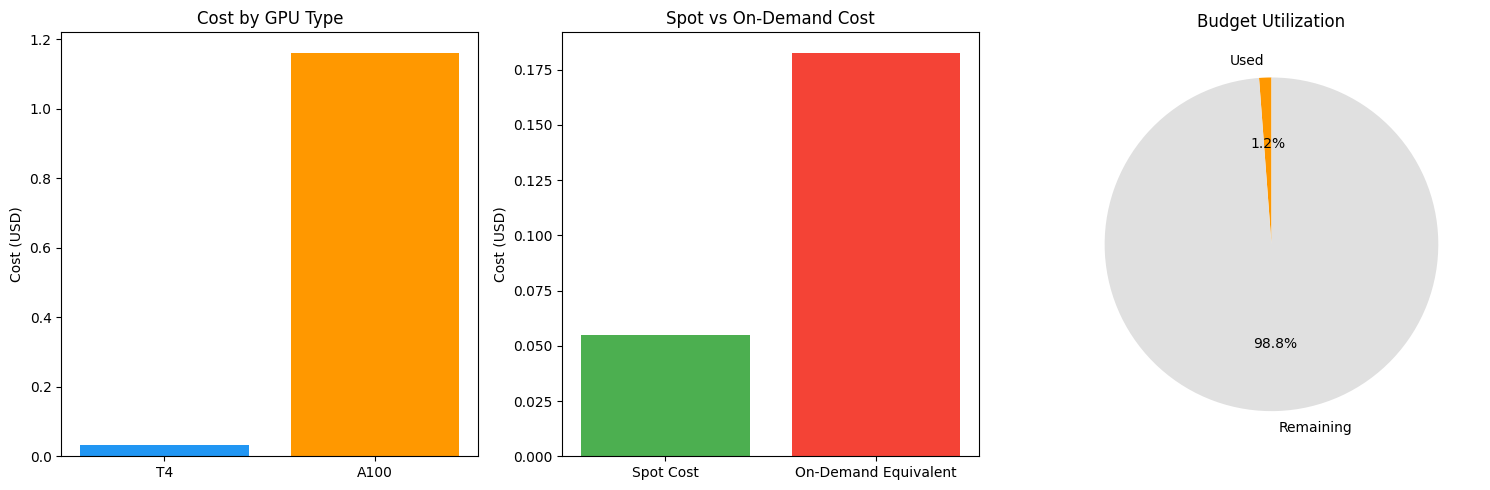

📊 Chart saved as finops_cost_breakdown.png


In [17]:
# Cell 16: Cost Breakdown Visualization
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Cost by GPU type
cost_by_type = summary.get('cost_by_gpu_type', {})
if cost_by_type:
    types = list(cost_by_type.keys())
    costs = [cost_by_type[t]['cost'] for t in types]
    axes[0].bar(types, costs, color=['#2196F3', '#FF9800', '#4CAF50'])
    axes[0].set_title('Cost by GPU Type')
    axes[0].set_ylabel('Cost (USD)')

# Chart 2: Spot vs On-Demand
spot_data = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
labels = ['Spot Cost', 'On-Demand Equivalent']
values = [spot_data.get('total_spot_cost', 0), spot_data.get('on_demand_equivalent', 0)]
axes[1].bar(labels, values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Spot vs On-Demand Cost')
axes[1].set_ylabel('Cost (USD)')

# Chart 3: Budget utilization
budget_used = summary.get('budget_utilization_pct', 0)
axes[2].pie([budget_used, 100-budget_used], labels=['Used', 'Remaining'],
            colors=['#FF9800', '#E0E0E0'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Budget Utilization')

plt.tight_layout()
plt.savefig('finops_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as finops_cost_breakdown.png")

📈 Collecting time-series data (10 snapshots)...


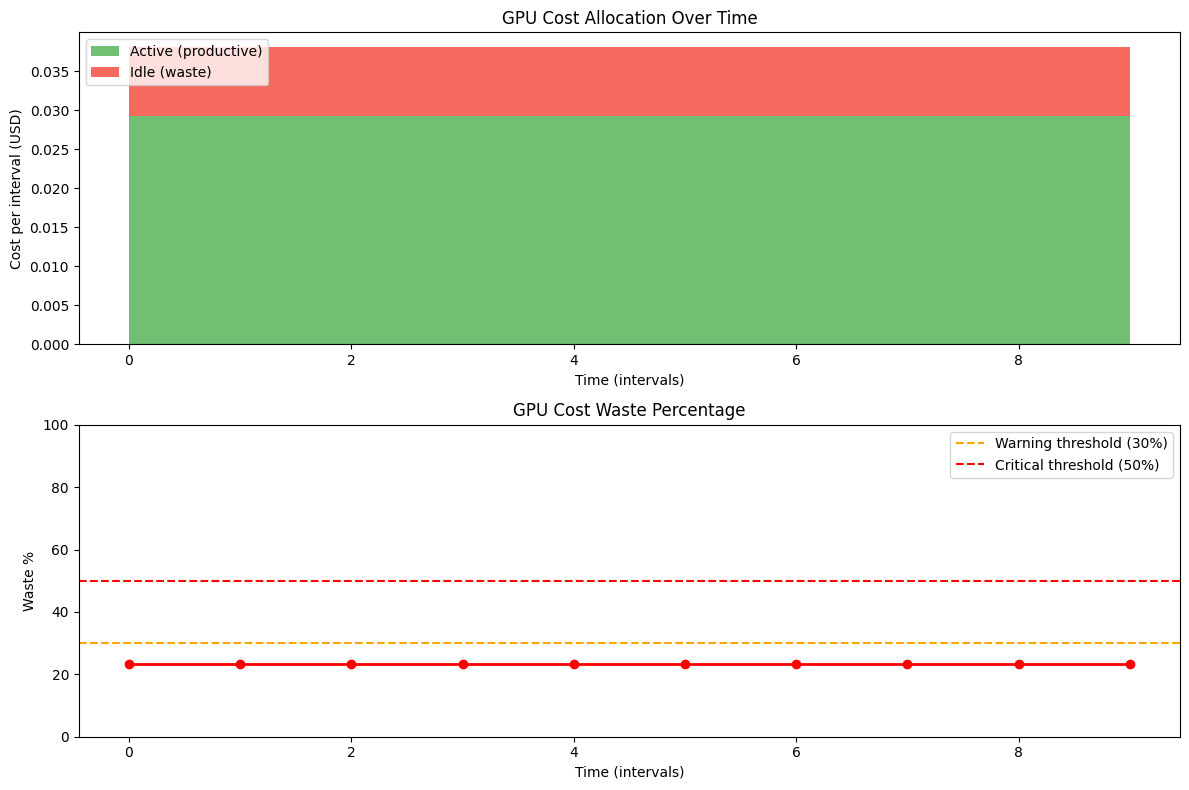

In [18]:
# Cell 17: Time-series cost tracking
print("📈 Collecting time-series data (10 snapshots)...")
ts_data = []
for i in range(10):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    ts_data.append({
        'time': i,
        'total_cost': snap['total_cost_usd'],
        'idle_cost': snap['total_idle_cost_usd'],
        'active_cost': snap['total_active_cost_usd'],
        'waste_pct': snap['waste_pct'],
    })
    time.sleep(1)

df = pd.DataFrame(ts_data)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Cost over time
ax1.stackplot(df['time'], df['active_cost'], df['idle_cost'],
              labels=['Active (productive)', 'Idle (waste)'],
              colors=['#4CAF50', '#F44336'], alpha=0.8)
ax1.set_xlabel('Time (intervals)')
ax1.set_ylabel('Cost per interval (USD)')
ax1.set_title('GPU Cost Allocation Over Time')
ax1.legend(loc='upper left')

# Waste percentage
ax2.plot(df['time'], df['waste_pct'], 'r-o', linewidth=2)
ax2.axhline(y=30, color='orange', linestyle='--', label='Warning threshold (30%)')
ax2.axhline(y=50, color='red', linestyle='--', label='Critical threshold (50%)')
ax2.set_xlabel('Time (intervals)')
ax2.set_ylabel('Waste %')
ax2.set_title('GPU Cost Waste Percentage')
ax2.legend()
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('finops_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7: Complete FinOps Workflow
Run a full cycle: submit workloads → monitor → detect waste → autoscale → optimize cost.

In [19]:
# Cell 18: Full FinOps Optimization Workflow
print("🔄 FULL FINOPS OPTIMIZATION WORKFLOW")
print("=" * 60)

# Step 1: Check initial state
print("\n1️⃣  Initial cluster state:")
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   GPUs: {m['total_gpus']} | Util: {m['avg_utilization']:.1f}% | Idle: {m['idle_gpus']}")

# Step 2: Submit heavy workloads to increase utilization
print("\n2️⃣  Submitting heavy workloads...")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 600
    })
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   After load: Util: {m['avg_utilization']:.1f}% | Busy: {m['busy_gpus']}/{m['total_gpus']}")

# Step 3: Autoscaler evaluates
print("\n3️⃣  Autoscaler evaluation:")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
print(f"   Decision: {decision['action']} - {decision['reason']}")

# Step 4: Cost snapshot
print("\n4️⃣  Cost analysis:")
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"   Total cost/interval: ${snap['total_cost_usd']:.6f}")
print(f"   Waste: {snap['waste_pct']:.1f}%")

# Step 5: Get recommendations
print("\n5️⃣  Recommendations:")
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()
for rec in recs:
    print(f"   [{rec['priority']}] {rec['type']}: savings ~{rec['estimated_savings_pct']}%")

# Step 6: Apply optimization - use spot for some workloads
print("\n6️⃣  Applying optimization: Switch to spot instances...")
for i in range(3):
    requests.post(f"{GATEWAY_URL}/spot/request", json={
        "instance_id": f"opt-spot-{i}", "gpu_type": "T4",
        "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": f"heavy-{i:03d}"
    })

savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot savings: ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

# Step 7: Complete workloads and record billing
print("\n7️⃣  Final billing:")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/heavy-{i:03d}/complete")
    requests.post(f"{GATEWAY_URL}/billing/record", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type": "T4",
        "gpu_count": 1, "duration_seconds": 600, "is_spot": i < 3
    })

final = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total spend: ${final['total_cost_usd']:.4f}")
print(f"   Total saved: ${final['total_savings_usd']:.4f}")
print(f"   Budget: {final['budget_utilization_pct']:.1f}% used")
print(f"\n✅ Workflow complete!")

🔄 FULL FINOPS OPTIMIZATION WORKFLOW

1️⃣  Initial cluster state:
   GPUs: 8 | Util: 53.1% | Idle: 3

2️⃣  Submitting heavy workloads...
   After load: Util: 79.9% | Busy: 8/8

3️⃣  Autoscaler evaluation:
   Decision: scale_up - Utilization 79.9% > threshold 70.0%

4️⃣  Cost analysis:
   Total cost/interval: $0.040000
   Waste: 4.9%

5️⃣  Recommendations:
   [MEDIUM] USE_SPOT: savings ~65.0%
   [LOW] SCHEDULING: savings ~20.0%

6️⃣  Applying optimization: Switch to spot instances...
   Spot savings: $0.1814 (70.0%)

7️⃣  Final billing:
   Total spend: $1.3640
   Total saved: $1.4151
   Budget: 1.4% used

✅ Workflow complete!


---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** to measure time & cost savings
4. Reports all costs back to the FinOps gateway

In [20]:
# Cell 19: Install dependencies & detect real GPU
!pip install -q torch torchvision pynvml

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import subprocess
import threading

try:
    from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex,
                        nvmlDeviceGetUtilizationRates, nvmlDeviceGetMemoryInfo,
                        nvmlDeviceGetPowerUsage, nvmlDeviceGetTemperature)
    PYNVML_AVAILABLE = True
except ImportError:
    PYNVML_AVAILABLE = False
    print("pynvml not available, will use torch.cuda fallback for monitoring")

# Detect GPU
if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Enable GPU in Kaggle/Colab settings.")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9

# Map real GPU to pricing
GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}
detected_type = "T4"  # default
for gtype in GPU_PRICING:
    if gtype.lower() in gpu_name.lower():
        detected_type = gtype
        break

print(f"Real GPU Detected")
print(f"   Name:    {gpu_name}")
print(f"   Memory:  {gpu_mem:.1f} GB")
print(f"   Type:    {detected_type}")
print(f"   Pricing: ${GPU_PRICING[detected_type]:.2f}/hr (on-demand)")
print(f"   CUDA:    {torch.version.cuda}")
print(f"   pynvml:  {'available' if PYNVML_AVAILABLE else 'NOT available'}")

Real GPU Detected
   Name:    Tesla T4
   Memory:  15.6 GB
   Type:    T4
   Pricing: $0.35/hr (on-demand)
   CUDA:    12.8
   pynvml:  available


In [21]:
# Cell 20: GPU Metrics Collection (works on Kaggle/Colab)
# Strategy: pynvml first (reliable Python lib), torch.cuda fallback

def get_gpu_metrics():
    """Get GPU metrics inline. Called during training loop."""

    # Method 1: pynvml (most reliable on Kaggle - pure Python, no subprocess)
    if PYNVML_AVAILABLE:
        try:
            nvmlInit()
            handle = nvmlDeviceGetHandleByIndex(0)
            util = nvmlDeviceGetUtilizationRates(handle)
            mem_info = nvmlDeviceGetMemoryInfo(handle)
            try:
                power = nvmlDeviceGetPowerUsage(handle) / 1000.0  # mW -> W
            except Exception:
                power = 0.0
            try:
                temp = nvmlDeviceGetTemperature(handle, 0)  # NVML_TEMPERATURE_GPU = 0
            except Exception:
                temp = 0.0
            return {
                'timestamp': time.time(),
                'gpu_util_pct': float(util.gpu),
                'mem_util_pct': float(util.memory),
                'mem_used_mb': mem_info.used / 1e6,
                'mem_total_mb': mem_info.total / 1e6,
                'power_watts': float(power),
                'temp_c': float(temp),
            }
        except Exception as e:
            pass  # Fall through to torch.cuda

    # Method 2: torch.cuda (always works, limited metrics)
    mem_used = torch.cuda.memory_allocated() / 1e6
    mem_reserved = torch.cuda.memory_reserved() / 1e6
    mem_total = torch.cuda.get_device_properties(0).total_memory / 1e6
    util_approx = (mem_reserved / mem_total) * 100 if mem_total > 0 else 0
    return {
        'timestamp': time.time(),
        'gpu_util_pct': util_approx,
        'mem_util_pct': util_approx,
        'mem_used_mb': mem_used,
        'mem_total_mb': mem_total,
        'power_watts': 0.0,
        'temp_c': 0.0,
    }

# === DIAGNOSTIC TEST ===
print("=" * 50)
print("GPU METRICS DIAGNOSTIC")
print("=" * 50)

# Test pynvml
print(f"\n1. pynvml available: {PYNVML_AVAILABLE}")
if PYNVML_AVAILABLE:
    try:
        nvmlInit()
        handle = nvmlDeviceGetHandleByIndex(0)
        util = nvmlDeviceGetUtilizationRates(handle)
        mem = nvmlDeviceGetMemoryInfo(handle)
        print(f"   pynvml works! GPU util={util.gpu}%, mem={mem.used/1e6:.0f}/{mem.total/1e6:.0f} MB")
        try:
            pwr = nvmlDeviceGetPowerUsage(handle) / 1000.0
            print(f"   Power: {pwr:.1f}W")
        except Exception as e:
            print(f"   Power: not available ({e})")
        try:
            tmp = nvmlDeviceGetTemperature(handle, 0)
            print(f"   Temp: {tmp}C")
        except Exception as e:
            print(f"   Temp: not available ({e})")
    except Exception as e:
        print(f"   pynvml FAILED: {e}")

# Test full function
print(f"\n2. get_gpu_metrics() test:")
test_result = get_gpu_metrics()
for k, v in sorted(test_result.items()):
    if k != 'timestamp':
        print(f"   {k}: {v}")

print(f"\n   Method: {'pynvml' if test_result.get('temp_c', 0) > 0 or (PYNVML_AVAILABLE and test_result.get('gpu_util_pct', -1) >= 0) else 'torch.cuda'}")
print(f"\nReady for training.")

GPU METRICS DIAGNOSTIC

1. pynvml available: True
   pynvml works! GPU util=0%, mem=472/16106 MB
   Power: 10.1W
   Temp: 37C

2. get_gpu_metrics() test:
   gpu_util_pct: 0.0
   mem_total_mb: 16106.12736
   mem_used_mb: 472.055808
   mem_util_pct: 0.0
   power_watts: 10.059
   temp_c: 37.0

   Method: pynvml

Ready for training.


In [22]:
# Cell 21: Prepare CIFAR-10 dataset and ResNet-18 model
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
]))
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

print(f"Dataset ready: {len(trainset)} train / {len(testset)} test images")
print(f"Batches per epoch: {len(trainloader)}")


def create_model():
    """Create a fresh ResNet-18 for CIFAR-10."""
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.cuda()


def train_epoch_monitored(model, loader, optimizer, criterion, use_amp=False, sample_interval=10):
    """Train one epoch with inline GPU metrics collection every N batches."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = GradScaler() if use_amp else None
    metrics_samples = []
    start = time.time()

    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.cuda(), targets.cuda()
        optimizer.zero_grad()

        if use_amp:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)

        # Collect GPU metrics every N batches (inline, no threading)
        if batch_idx % sample_interval == 0:
            torch.cuda.synchronize()
            sample = get_gpu_metrics()
            metrics_samples.append(sample)

    elapsed = time.time() - start
    return total_loss / total, correct / total * 100, elapsed, metrics_samples


print("Model & training functions ready (inline monitoring every 10 batches)")

100%|██████████| 170M/170M [00:04<00:00, 39.5MB/s] 


Dataset ready: 50000 train / 10000 test images
Batches per epoch: 391
Model & training functions ready (inline monitoring every 10 batches)


In [23]:
# Cell 22: Train FP32 (baseline) with inline GPU monitoring
NUM_EPOCHS = 3
price_per_hour = GPU_PRICING[detected_type]

print("=" * 60)
print("EXPERIMENT 1: FP32 Training (Baseline)")
print("=" * 60)

model_fp32 = create_model()
optimizer_fp32 = optim.SGD(model_fp32.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
fp32_start = time.time()

fp32_results = []
fp32_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_fp32, trainloader, optimizer_fp32, criterion, use_amp=False)
    fp32_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    fp32_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

fp32_total_time = time.time() - fp32_start
fp32_peak_mem = torch.cuda.max_memory_allocated() / 1e9
fp32_cost = (fp32_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(fp32_all_metrics)}")

# Build monitor dataframe
fp32_monitor_df = pd.DataFrame(fp32_all_metrics)
if not fp32_monitor_df.empty and 'timestamp' in fp32_monitor_df.columns:
    fp32_monitor_df['elapsed'] = fp32_monitor_df['timestamp'] - fp32_monitor_df['timestamp'].iloc[0]

print(f"\n   FP32 Summary:")
print(f"   Total time:      {fp32_total_time:.1f}s")
print(f"   Peak memory:     {fp32_peak_mem:.2f} GB")
if not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns:
    print(f"   Avg GPU util:    {fp32_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {fp32_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {fp32_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {fp32_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(fp32_monitor_df.columns) if not fp32_monitor_df.empty else 'EMPTY'}")
    if fp32_all_metrics:
        print(f"   First sample keys: {list(fp32_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${fp32_cost:.6f}")

EXPERIMENT 1: FP32 Training (Baseline)
   Epoch 1/3 | Loss: 2.1139 | Acc: 24.5% | Time: 39.4s | Samples: 40
   Epoch 2/3 | Loss: 1.4894 | Acc: 44.8% | Time: 39.0s | Samples: 40
   Epoch 3/3 | Loss: 1.1930 | Acc: 57.0% | Time: 40.1s | Samples: 40

   Total samples collected: 120

   FP32 Summary:
   Total time:      118.5s
   Peak memory:     0.82 GB
   Avg GPU util:    94.3%
   Avg power:       67.8W
   Avg temperature: 61.7C
   Max GPU util:    98.0%
   Estimated cost:  $0.011523


In [24]:
# Cell 23: Train Mixed Precision AMP (optimized) with inline GPU monitoring
print("=" * 60)
print("EXPERIMENT 2: Mixed Precision (AMP) Training")
print("=" * 60)

model_amp = create_model()
optimizer_amp = optim.SGD(model_amp.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
amp_start = time.time()

amp_results = []
amp_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_amp, trainloader, optimizer_amp, criterion, use_amp=True)
    amp_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    amp_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

amp_total_time = time.time() - amp_start
amp_peak_mem = torch.cuda.max_memory_allocated() / 1e9
amp_cost = (amp_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(amp_all_metrics)}")

# Build monitor dataframe
amp_monitor_df = pd.DataFrame(amp_all_metrics)
if not amp_monitor_df.empty and 'timestamp' in amp_monitor_df.columns:
    amp_monitor_df['elapsed'] = amp_monitor_df['timestamp'] - amp_monitor_df['timestamp'].iloc[0]

print(f"\n   AMP Summary:")
print(f"   Total time:      {amp_total_time:.1f}s")
print(f"   Peak memory:     {amp_peak_mem:.2f} GB")
if not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns:
    print(f"   Avg GPU util:    {amp_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {amp_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {amp_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {amp_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(amp_monitor_df.columns) if not amp_monitor_df.empty else 'EMPTY'}")
    if amp_all_metrics:
        print(f"   First sample keys: {list(amp_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${amp_cost:.6f}")

EXPERIMENT 2: Mixed Precision (AMP) Training


/tmp/ipykernel_57/927799492.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
/tmp/ipykernel_57/927799492.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Epoch 1/3 | Loss: 1.9306 | Acc: 30.1% | Time: 19.2s | Samples: 40
   Epoch 2/3 | Loss: 1.3772 | Acc: 49.4% | Time: 19.0s | Samples: 40
   Epoch 3/3 | Loss: 1.0874 | Acc: 61.2% | Time: 19.0s | Samples: 40

   Total samples collected: 120

   AMP Summary:
   Total time:      57.3s
   Peak memory:     0.60 GB
   Avg GPU util:    89.0%
   Avg power:       65.7W
   Avg temperature: 77.9C
   Max GPU util:    92.0%
   Estimated cost:  $0.005570


FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)

Metric                    FP32            AMP             Improvement
----------------------------------------------------------------------
Total Time                118.5           57.3            2.07x faster
Peak Memory (GB)          0.82            0.60            0.22 GB saved
Cost (USD)                $0.011523       $0.005570       $0.005953 saved
Cost Saving %             ---             ---             51.7%
Avg GPU Util %            94.3            89.0           
Avg Power (W)             67.8            65.7           

--- Extrapolated Savings at Scale ---
   1 day training: FP32=$8.40 vs AMP=$4.06 -> SAVE $4.34
   1 week training: FP32=$58.80 vs AMP=$28.42 -> SAVE $30.38
   1 month training: FP32=$252.00 vs AMP=$121.82 -> SAVE $130.18


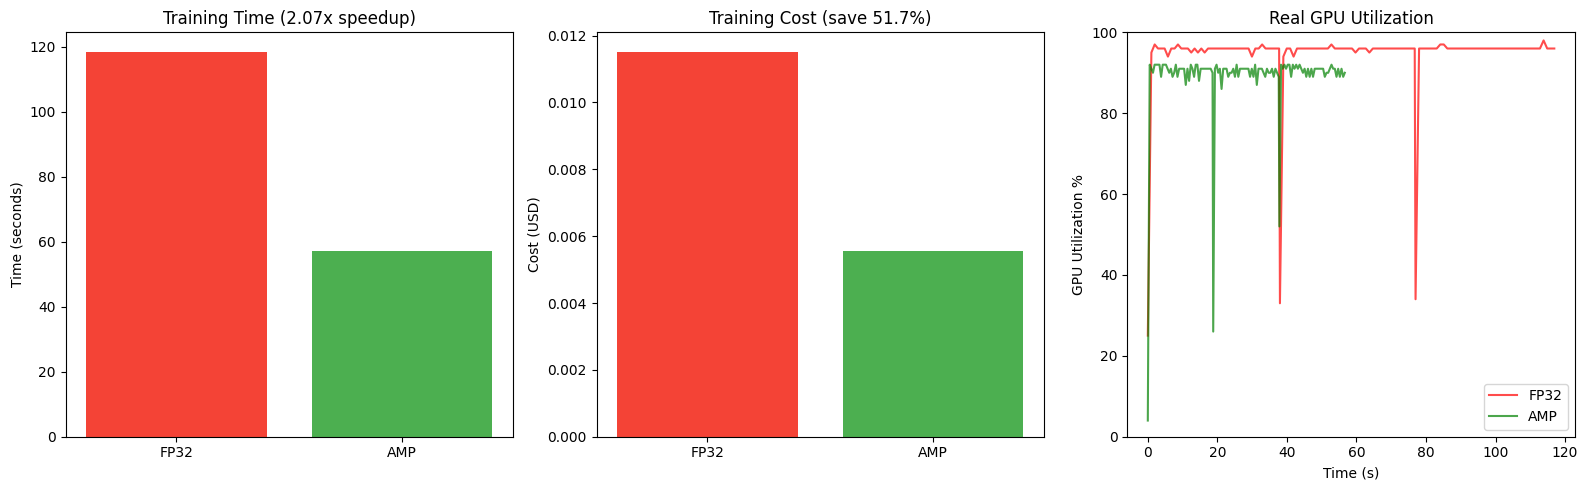

In [25]:
# Cell 24: Compare FP32 vs AMP - FinOps Analysis
print("=" * 60)
print("FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)")
print("=" * 60)

speedup = fp32_total_time / amp_total_time
cost_saving = fp32_cost - amp_cost
cost_saving_pct = (cost_saving / fp32_cost) * 100 if fp32_cost > 0 else 0
mem_saving = fp32_peak_mem - amp_peak_mem

print(f"\n{'Metric':<25} {'FP32':<15} {'AMP':<15} {'Improvement'}")
print("-" * 70)
print(f"{'Total Time':<25} {fp32_total_time:<15.1f} {amp_total_time:<15.1f} {speedup:.2f}x faster")
print(f"{'Peak Memory (GB)':<25} {fp32_peak_mem:<15.2f} {amp_peak_mem:<15.2f} {mem_saving:.2f} GB saved")
print(f"{'Cost (USD)':<25} ${fp32_cost:<14.6f} ${amp_cost:<14.6f} ${cost_saving:.6f} saved")
print(f"{'Cost Saving %':<25} {'---':<15} {'---':<15} {cost_saving_pct:.1f}%")

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    print(f"{'Avg GPU Util %':<25} {fp32_monitor_df['gpu_util_pct'].mean():<15.1f} {amp_monitor_df['gpu_util_pct'].mean():<15.1f}")
    print(f"{'Avg Power (W)':<25} {fp32_monitor_df['power_watts'].mean():<15.1f} {amp_monitor_df['power_watts'].mean():<15.1f}")

# Extrapolate to larger scale
print(f"\n--- Extrapolated Savings at Scale ---")
for scale_name, hours in [("1 day training", 24), ("1 week training", 168), ("1 month training", 720)]:
    fp32_scaled = hours * price_per_hour
    amp_scaled = (hours / speedup) * price_per_hour
    saved = fp32_scaled - amp_scaled
    print(f"   {scale_name}: FP32=${fp32_scaled:.2f} vs AMP=${amp_scaled:.2f} -> SAVE ${saved:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar: Time comparison
axes[0].bar(['FP32', 'AMP'], [fp32_total_time, amp_total_time], color=['#F44336', '#4CAF50'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title(f'Training Time ({speedup:.2f}x speedup)')

# Bar: Cost comparison
axes[1].bar(['FP32', 'AMP'], [fp32_cost, amp_cost], color=['#F44336', '#4CAF50'])
axes[1].set_ylabel('Cost (USD)')
axes[1].set_title(f'Training Cost (save {cost_saving_pct:.1f}%)')

# Line: GPU utilization over time (both experiments) or epoch time
if has_monitor_data:
    if not fp32_monitor_df.empty:
        axes[2].plot(fp32_monitor_df['elapsed'], fp32_monitor_df['gpu_util_pct'], 'r-', alpha=0.7, label='FP32')
    if not amp_monitor_df.empty:
        axes[2].plot(amp_monitor_df['elapsed'], amp_monitor_df['gpu_util_pct'], 'g-', alpha=0.7, label='AMP')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('GPU Utilization %')
    axes[2].set_title('Real GPU Utilization')
    axes[2].legend()
    axes[2].set_ylim(0, 100)
else:
    # Fallback: show epoch times
    epochs = list(range(1, NUM_EPOCHS + 1))
    axes[2].plot(epochs, [r['time_s'] for r in fp32_results], 'r-o', label='FP32')
    axes[2].plot(epochs, [r['time_s'] for r in amp_results], 'g-o', label='AMP')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Time (s)')
    axes[2].set_title('Time per Epoch')
    axes[2].legend()

plt.tight_layout()
plt.savefig('real_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Cell 25: Report real GPU costs back to the FinOps Gateway
print("=" * 60)
print("REPORTING REAL GPU COSTS TO FINOPS GATEWAY")
print("=" * 60)

# Report FP32 workload
fp32_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-fp32",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": fp32_total_time,
    "is_spot": False,
    "project": "real-gpu-lab",
}).json()
print(f"\n   FP32 workload reported:")
print(f"   Cost: ${fp32_report['total_cost_usd']:.6f} | Rate: ${fp32_report['rate_per_hour']:.4f}/hr")

# Report AMP workload (as spot - demonstrating cost optimization)
amp_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-amp",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": amp_total_time,
    "is_spot": True,
    "project": "real-gpu-lab",
}).json()
print(f"\n   AMP workload reported (as spot):")
print(f"   Cost: ${amp_report['total_cost_usd']:.6f} | Saved: ${amp_report['savings_usd']:.6f}")

# Submit workload info to cluster tracker
for wl_name, wl_time in [("real-gpu-resnet18-fp32", fp32_total_time), ("real-gpu-resnet18-amp", amp_total_time)]:
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": wl_name,
        "gpu_type_preferred": detected_type,
        "gpu_count": 1,
        "duration_seconds": int(wl_time),
    })

# Get updated billing summary including real GPU data
print(f"\n--- Updated FinOps Billing (incl. real GPU) ---")
summary = requests.get(f"{GATEWAY_URL}/billing/summary", params={"project": "real-gpu-lab"}).json()
print(f"   Project:         real-gpu-lab")
print(f"   Total Cost:      ${summary['total_cost_usd']:.6f}")
print(f"   Total Savings:   ${summary['total_savings_usd']:.6f}")
print(f"   Workloads:       {summary['total_workloads']}")

# Push real GPU metrics as a cost snapshot
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"\n   Cost snapshot taken: waste={snap['waste_pct']:.1f}%")

# Get final dashboard with everything
print(f"\n--- FINAL DASHBOARD (Mock + Real GPU) ---")
dash = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()
bs = dash.get('billing_summary', {})
print(f"   Total Platform Cost:  ${bs.get('total_cost_usd', 0):.4f}")
print(f"   Total Savings:        ${bs.get('total_savings_usd', 0):.4f}")
print(f"   Budget Utilization:   {bs.get('budget_utilization_pct', 0):.1f}%")
print(f"   Alert:                {bs.get('alert', 'N/A')}")

REPORTING REAL GPU COSTS TO FINOPS GATEWAY

   FP32 workload reported:
   Cost: $0.011500 | Rate: $0.3500/hr

   AMP workload reported (as spot):
   Cost: $0.001700 | Saved: $0.003900

--- Updated FinOps Billing (incl. real GPU) ---
   Project:         real-gpu-lab
   Total Cost:      $0.013200
   Total Savings:   $0.003900
   Workloads:       2

   Cost snapshot taken: waste=22.1%

--- FINAL DASHBOARD (Mock + Real GPU) ---
   Total Platform Cost:  $1.3640
   Total Savings:        $1.4151
   Budget Utilization:   1.4%
   Alert:                OK


Real GPU Telemetry During Training


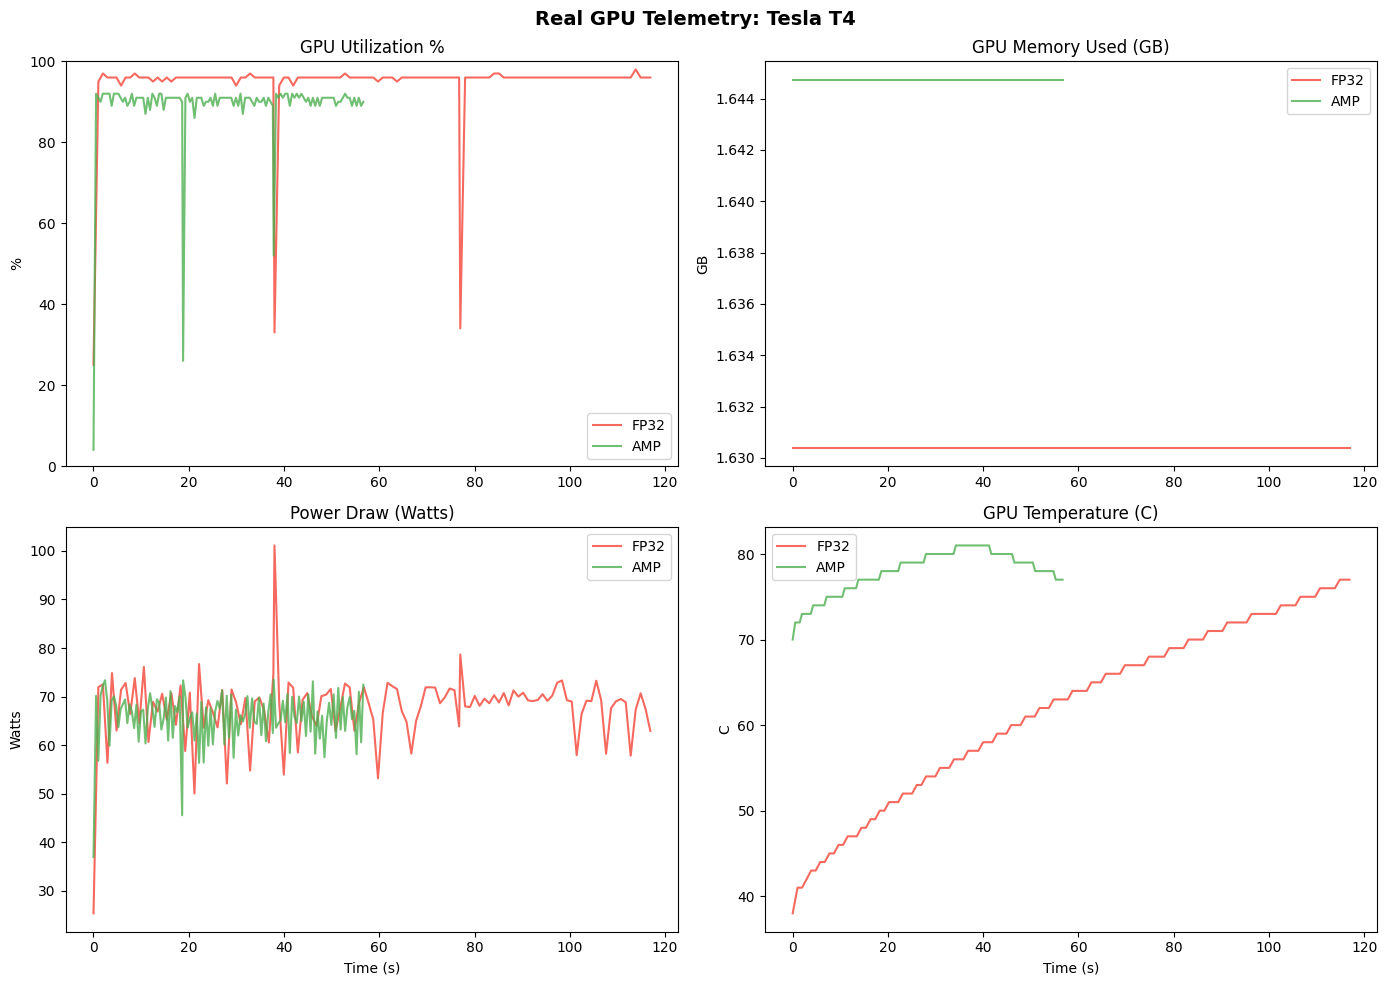

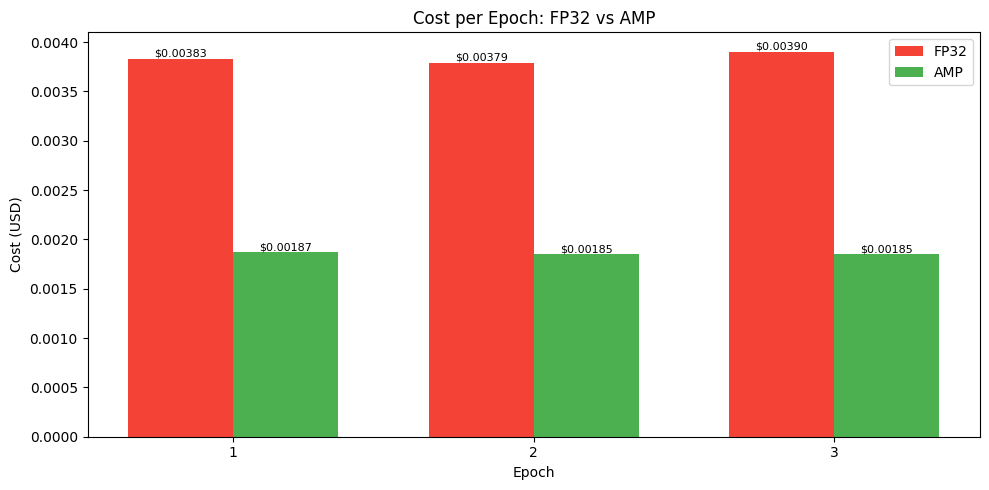


Charts saved: cost_per_epoch.png, real_gpu_telemetry.png


In [27]:
# Cell 26: Real GPU Monitoring Visualization
print("Real GPU Telemetry During Training")
print("=" * 60)

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # GPU Utilization
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 0].plot(df['elapsed'], df['gpu_util_pct'], color=color, alpha=0.8, label=label)
    axes[0, 0].set_title('GPU Utilization %')
    axes[0, 0].set_ylabel('%')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 100)

    # Memory Usage
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 1].plot(df['elapsed'], df['mem_used_mb'] / 1024, color=color, alpha=0.8, label=label)
    axes[0, 1].set_title('GPU Memory Used (GB)')
    axes[0, 1].set_ylabel('GB')
    axes[0, 1].legend()

    # Power Draw
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 0].plot(df['elapsed'], df['power_watts'], color=color, alpha=0.8, label=label)
    axes[1, 0].set_title('Power Draw (Watts)')
    axes[1, 0].set_ylabel('Watts')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].legend()

    # Temperature
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 1].plot(df['elapsed'], df['temp_c'], color=color, alpha=0.8, label=label)
    axes[1, 1].set_title('GPU Temperature (C)')
    axes[1, 1].set_ylabel('C')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].legend()

    plt.suptitle(f'Real GPU Telemetry: {gpu_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('real_gpu_telemetry.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("   GPU telemetry not available (monitor collected 0 samples).")
    print("   Showing epoch-level metrics instead.\n")

# Cost per epoch chart (always works)
fig, ax = plt.subplots(figsize=(10, 5))
fp32_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in fp32_results]
amp_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in amp_results]
epochs = list(range(1, NUM_EPOCHS + 1))

x = range(len(epochs))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], fp32_epoch_costs, width, label='FP32', color='#F44336')
bars2 = ax.bar([i + width/2 for i in x], amp_epoch_costs, width, label='AMP', color='#4CAF50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cost (USD)')
ax.set_title('Cost per Epoch: FP32 vs AMP')
ax.set_xticks(x)
ax.set_xticklabels(epochs)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cost_per_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCharts saved: cost_per_epoch.png" + (", real_gpu_telemetry.png" if has_monitor_data else ""))

---
## Part 8.5: Advanced GPU Cost Optimization
Apply advanced FinOps techniques: multi-GPU cost analysis, project forecasting, and optimization strategy prioritization.

This section extends Part 8 with:
1. **Multi-GPU Cost Analysis** - Compare scaling efficiency and determine optimal GPU count
2. **Project Cost Forecasting** - Forecast multi-phase project costs with confidence intervals
3. **Optimization Opportunity Analysis** - Prioritize and combine optimization strategies

EXERCISE 8.5.1: Multi-GPU Cost Analysis

Using baseline: 0.0329h on 1x T4 ($0.35/hr)

Multi-GPU comparison table:


,gpu_count,speedup,efficiency_pct,runtime_hours,total_cost_usd,time_saved_pct,cost_per_speedup_unit
0,1,1.0,100.0,0.0329,0.0115,0.0,0.0115
1,2,1.8,90.0,0.0183,0.0128,44.4,0.0071
2,4,3.3,82.5,0.0100,0.0140,69.7,0.0042
3,8,5.8,72.5,0.0057,0.0159,82.8,0.0027



Key takeaways:
   Lowest absolute cost: 1 GPU(s) -> $0.0115
   Fastest runtime:      8 GPU(s) -> 0.0057h
   Best cost/perf:       8 GPU(s) -> $0.0027 per speedup unit


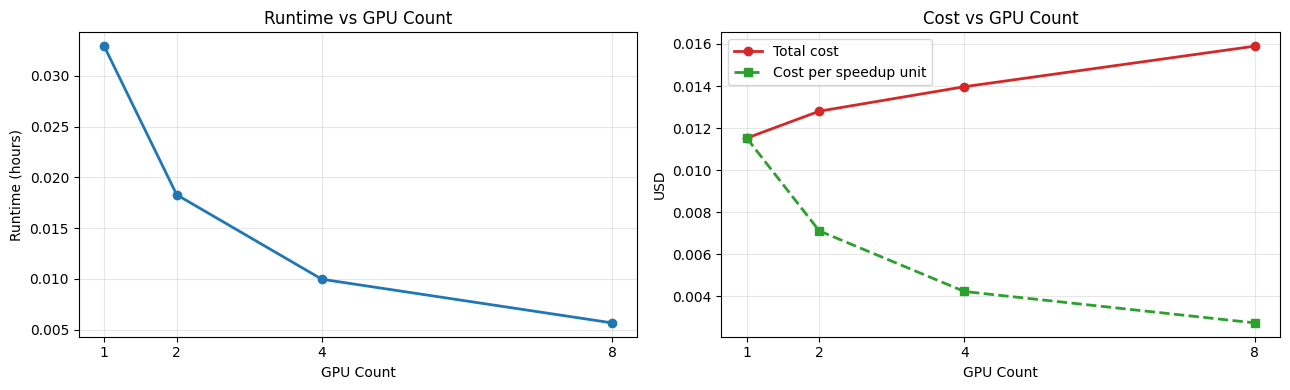


Chart saved as: multi_gpu_scaling.png


In [47]:
# Cell 27: Multi-GPU Cost Analysis
print("=" * 60)
print("EXERCISE 8.5.1: Multi-GPU Cost Analysis")
print("=" * 60)

# Model the tradeoff between runtime reduction and total spend as GPU count grows.
# More GPUs improve time-to-train, but scaling is usually sub-linear.
import math

def analyze_multi_gpu_cost(base_time_hours, gpu_type, gpu_counts, scaling_factors=None):
    """Analyze runtime, total cost, and scaling efficiency across GPU counts."""
    if gpu_type not in GPU_PRICING:
        raise ValueError(f"Unknown gpu_type: {gpu_type}. Available: {list(GPU_PRICING.keys())}")

    gpu_counts = sorted(set(gpu_counts))
    price_per_hour = GPU_PRICING[gpu_type]

    if scaling_factors is None:
        default_speedups = {1: 1.0, 2: 1.8, 4: 3.3, 8: 5.8}
        scaling_factors = {}
        for count in gpu_counts:
            if count in default_speedups:
                scaling_factors[count] = default_speedups[count]
            else:
                efficiency = max(0.55, 0.92 - 0.08 * math.log2(count))
                scaling_factors[count] = round(count * efficiency, 2)

    rows = []
    for count in gpu_counts:
        speedup = scaling_factors.get(count, float(count))
        if speedup <= 0:
            raise ValueError(f"Scaling factor for {count} GPUs must be > 0")

        runtime_hours = base_time_hours / speedup
        total_cost = runtime_hours * price_per_hour * count
        efficiency_pct = (speedup / count) * 100
        time_saved_pct = (1 - runtime_hours / base_time_hours) * 100
        cost_per_speedup = total_cost / speedup

        rows.append({
            'gpu_count': count,
            'speedup': speedup,
            'efficiency_pct': efficiency_pct,
            'runtime_hours': runtime_hours,
            'total_cost_usd': total_cost,
            'time_saved_pct': time_saved_pct,
            'cost_per_speedup_unit': cost_per_speedup,
        })

    df = pd.DataFrame(rows)
    cheapest_idx = df['total_cost_usd'].idxmin()
    fastest_idx = df['runtime_hours'].idxmin()
    best_value_idx = df['cost_per_speedup_unit'].idxmin()

    return {
        'gpu_type': gpu_type,
        'price_per_hour': price_per_hour,
        'base_time_hours': base_time_hours,
        'scaling_factors': scaling_factors,
        'table': df,
        'cheapest_config': df.loc[cheapest_idx].to_dict(),
        'fastest_config': df.loc[fastest_idx].to_dict(),
        'best_value_config': df.loc[best_value_idx].to_dict(),
    }

# Prefer the real FP32 experiment as the baseline if it already ran.
base_training_time = fp32_total_time / 3600 if 'fp32_total_time' in globals() else 2.0
analysis_gpu_type = detected_type if 'detected_type' in globals() else 'T4'
test_gpu_counts = [1, 2, 4, 8]

analysis = analyze_multi_gpu_cost(
    base_time_hours=base_training_time,
    gpu_type=analysis_gpu_type,
    gpu_counts=test_gpu_counts,
)

multi_gpu_df = analysis['table'].copy()
display_df = multi_gpu_df.copy()
display_df['speedup'] = display_df['speedup'].map(lambda x: round(x, 2))
display_df['efficiency_pct'] = display_df['efficiency_pct'].map(lambda x: round(x, 1))
display_df['runtime_hours'] = display_df['runtime_hours'].map(lambda x: round(x, 4))
display_df['total_cost_usd'] = display_df['total_cost_usd'].map(lambda x: round(x, 4))
display_df['time_saved_pct'] = display_df['time_saved_pct'].map(lambda x: round(x, 1))
display_df['cost_per_speedup_unit'] = display_df['cost_per_speedup_unit'].map(lambda x: round(x, 4))

print(f"\nUsing baseline: {base_training_time:.4f}h on 1x {analysis_gpu_type} (${analysis['price_per_hour']:.2f}/hr)")
print("\nMulti-GPU comparison table:")
display(display_df)

cheapest = analysis['cheapest_config']
fastest = analysis['fastest_config']
best_value = analysis['best_value_config']

print("\nKey takeaways:")
print(f"   Lowest absolute cost: {int(cheapest['gpu_count'])} GPU(s) -> ${cheapest['total_cost_usd']:.4f}")
print(f"   Fastest runtime:      {int(fastest['gpu_count'])} GPU(s) -> {fastest['runtime_hours']:.4f}h")
print(f"   Best cost/perf:       {int(best_value['gpu_count'])} GPU(s) -> ${best_value['cost_per_speedup_unit']:.4f} per speedup unit")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(multi_gpu_df['gpu_count'], multi_gpu_df['runtime_hours'], 'o-', color='#1f77b4', linewidth=2)
axes[0].set_title('Runtime vs GPU Count')
axes[0].set_xlabel('GPU Count')
axes[0].set_ylabel('Runtime (hours)')
axes[0].set_xticks(multi_gpu_df['gpu_count'])
axes[0].grid(alpha=0.3)

axes[1].plot(multi_gpu_df['gpu_count'], multi_gpu_df['total_cost_usd'], 'o-', color='#d62728', linewidth=2, label='Total cost')
axes[1].plot(multi_gpu_df['gpu_count'], multi_gpu_df['cost_per_speedup_unit'], 's--', color='#2ca02c', linewidth=2, label='Cost per speedup unit')
axes[1].set_title('Cost vs GPU Count')
axes[1].set_xlabel('GPU Count')
axes[1].set_ylabel('USD')
axes[1].set_xticks(multi_gpu_df['gpu_count'])
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('multi_gpu_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as: multi_gpu_scaling.png")


EXERCISE 8.5.2: Project Cost Forecasting

Phase-by-phase forecast:


,name,gpu_type,gpu_count,duration_hours,rate_per_hour,base_cost_usd,uncertainty_pct,uncertainty_usd,best_case_usd,worst_case_usd
0,Data Preparation,T4,1,40,0.35,14.0,15.0,2.10,11.90,16.10
1,Model Training,A100,4,120,3.67,1761.6,25.0,440.40,1321.20,2202.00
2,Hyperparameter Tuning,A100,8,60,3.67,1761.6,30.0,528.48,1233.12,2290.08
3,Model Evaluation,T4,2,20,0.35,14.0,10.0,1.40,12.60,15.40



Forecast summary:
   Base cost:           $3551.20
   Contingency (20%): $710.24
   Expected total:      $4261.44
   Best case:           $2578.82
   Worst case:          $5233.82
   95% CI:            $2913.09 to $5609.79


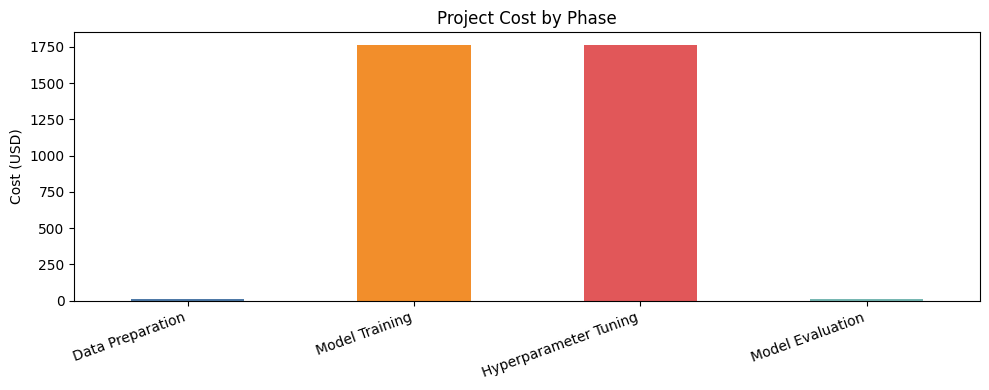


Chart saved as: project_forecast.png


In [48]:
# Cell 28: Project Cost Forecasting
print("=" * 60)
print("EXERCISE 8.5.2: Project Cost Forecasting")
print("=" * 60)

# TODO: Implement project cost forecasting with confidence intervals
# Hint: ML projects have multiple phases (data prep, training, tuning, deployment)

def forecast_project_cost(phases, contingency_pct=20, confidence_level=0.95):
    """
    TODO: Implement this function to forecast multi-phase project costs
    
    Parameters:
        phases (list): List of phase dictionaries, each with:
                      - name: str
                      - gpu_type: str
                      - gpu_count: int
                      - duration_hours: float
                      - uncertainty_pct: float (e.g., 0.2 for 20% uncertainty)
        contingency_pct (float): Percentage buffer for unexpected costs (default 20%)
        confidence_level (float): Confidence level for intervals (0.95 = 95%)
    
    Returns:
        dict: Forecast with base cost, contingency, confidence intervals
    """
    # TODO: Implement the function
    # - Calculate base cost for each phase using GPU_PRICING
    # - Calculate uncertainty range for each phase
    # - Sum all phases for total base cost
    # - Add contingency buffer
    # - Calculate confidence interval based on uncertainty
    # - Return forecast with breakdown
    z_lookup = {0.80: 1.28, 0.90: 1.64, 0.95: 1.96, 0.99: 2.58}
    z_score = z_lookup.get(round(confidence_level, 2), 1.96)

    breakdown = []
    variance_sum = 0.0
    for phase in phases:
        gpu_type = phase['gpu_type']
        if gpu_type not in GPU_PRICING:
            raise ValueError(f"Unknown gpu_type: {gpu_type}")

        rate = GPU_PRICING[gpu_type]
        phase_cost = phase['duration_hours'] * phase['gpu_count'] * rate
        uncertainty_pct = phase.get('uncertainty_pct', 0.0)
        uncertainty_usd = phase_cost * uncertainty_pct
        variance_sum += uncertainty_usd ** 2

        breakdown.append({
            'name': phase['name'],
            'gpu_type': gpu_type,
            'gpu_count': phase['gpu_count'],
            'duration_hours': phase['duration_hours'],
            'rate_per_hour': rate,
            'base_cost_usd': phase_cost,
            'uncertainty_pct': uncertainty_pct * 100,
            'uncertainty_usd': uncertainty_usd,
            'best_case_usd': max(0, phase_cost - uncertainty_usd),
            'worst_case_usd': phase_cost + uncertainty_usd,
        })

    df = pd.DataFrame(breakdown)
    base_cost = df['base_cost_usd'].sum()
    contingency_usd = base_cost * (contingency_pct / 100)
    expected_total = base_cost + contingency_usd
    aggregate_sigma = variance_sum ** 0.5
    ci_margin = aggregate_sigma * z_score

    return {
        'phases': df,
        'base_cost_usd': base_cost,
        'contingency_pct': contingency_pct,
        'contingency_usd': contingency_usd,
        'expected_total_usd': expected_total,
        'confidence_level': confidence_level,
        'confidence_interval_usd': (
            max(0, expected_total - ci_margin),
            expected_total + ci_margin,
        ),
        'best_case_usd': max(0, df['best_case_usd'].sum()),
        'worst_case_usd': df['worst_case_usd'].sum() + contingency_usd,
        'aggregate_sigma_usd': aggregate_sigma,
    }

# Example project phases
example_project = [
    {"name": "Data Preparation", "gpu_type": "T4", "gpu_count": 1, "duration_hours": 40, "uncertainty_pct": 0.15},
    {"name": "Model Training", "gpu_type": "A100", "gpu_count": 4, "duration_hours": 120, "uncertainty_pct": 0.25},
    {"name": "Hyperparameter Tuning", "gpu_type": "A100", "gpu_count": 8, "duration_hours": 60, "uncertainty_pct": 0.30},
    {"name": "Model Evaluation", "gpu_type": "T4", "gpu_count": 2, "duration_hours": 20, "uncertainty_pct": 0.10},
]

# TODO: Call the function and display forecast
# Hint: Show phase-by-phase breakdown, total with contingency, confidence interval

project_forecast = forecast_project_cost(example_project, contingency_pct=20, confidence_level=0.95)
project_forecast_df = project_forecast['phases'].copy()
for col in ['rate_per_hour', 'base_cost_usd', 'uncertainty_pct', 'uncertainty_usd', 'best_case_usd', 'worst_case_usd']:
    project_forecast_df[col] = project_forecast_df[col].map(lambda x: round(x, 2))

print("\nPhase-by-phase forecast:")
display(project_forecast_df)

ci_low, ci_high = project_forecast['confidence_interval_usd']
print("\nForecast summary:")
print(f"   Base cost:           ${project_forecast['base_cost_usd']:.2f}")
print(f"   Contingency ({project_forecast['contingency_pct']:.0f}%): ${project_forecast['contingency_usd']:.2f}")
print(f"   Expected total:      ${project_forecast['expected_total_usd']:.2f}")
print(f"   Best case:           ${project_forecast['best_case_usd']:.2f}")
print(f"   Worst case:          ${project_forecast['worst_case_usd']:.2f}")
print(f"   {int(project_forecast['confidence_level']*100)}% CI:            ${ci_low:.2f} to ${ci_high:.2f}")

fig, ax = plt.subplots(figsize=(10, 4))
phase_costs = project_forecast['phases'][['name', 'base_cost_usd']].set_index('name')['base_cost_usd']
phase_costs.plot(kind='bar', ax=ax, color=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2'])
ax.set_title('Project Cost by Phase')
ax.set_ylabel('Cost (USD)')
ax.set_xlabel('')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('project_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as: project_forecast.png")


EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis

Current baseline cost: $1468.00

Ranked optimization strategies:


,name,savings_pct,savings_usd,implementation_effort,risk_level,dependencies,priority_score
0,Switch to Mixed Precision (AMP),25.0,367.0,LOW,LOW,None,0.25
1,Use Spot Instances,60.0,880.8,MEDIUM,HIGH,None,0.21
2,Optimize Batch Size,15.0,220.2,LOW,LOW,None,0.15
3,Switch to More Efficient GPU Type,40.0,587.2,HIGH,MEDIUM,None,0.11
4,Implement Early Stopping,20.0,293.6,MEDIUM,LOW,None,0.11



Implementation roadmap:


,strategy,stage,dependency_ready,incremental_savings_usd,cumulative_savings_usd
0,Switch to Mixed Precision (AMP),Quick Win,True,367.00,367.00
1,Use Spot Instances,Strategic,True,660.60,1027.60
2,Optimize Batch Size,Quick Win,True,66.06,1093.66
3,Switch to More Efficient GPU Type,Transformational,True,149.74,1243.40
4,Implement Early Stopping,Strategic,True,44.92,1288.32



Summary:
   Max cumulative savings: $1288.32
   Optimized cost:         $179.68
   Top priority:           Switch to Mixed Precision (AMP)


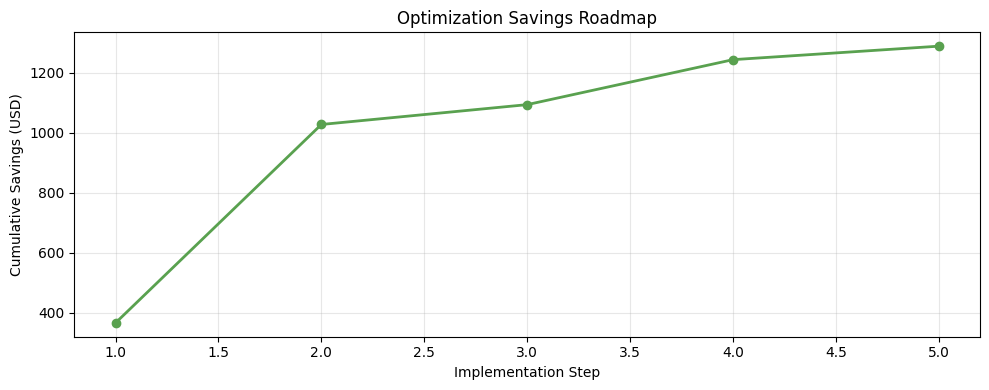


Chart saved as: optimization_roadmap.png


In [49]:
# Cell 29: Optimization Opportunity Analysis
print("=" * 60)
print("EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis")
print("=" * 60)

# TODO: Implement optimization opportunity analysis with prioritization
# Hint: Not all optimizations are equal - consider savings vs effort

def analyze_optimization_opportunities(current_config, optimization_strategies):
    """
    TODO: Implement this function to analyze and prioritize optimization strategies
    
    Parameters:
        current_config (dict): Current training configuration
                             (gpu_type, gpu_count, duration, precision, etc.)
        optimization_strategies (list): List of strategy dictionaries, each with:
                                      - name: str
                                      - savings_pct: float (estimated cost savings)
                                      - implementation_effort: str (LOW/MEDIUM/HIGH)
                                      - risk_level: str (LOW/MEDIUM/HIGH)
                                      - dependencies: list (other strategies required)
    
    Returns:
        dict: Prioritized recommendations with cumulative savings
    """
    # TODO: Implement the function
    # - Calculate potential savings for each strategy
    # - Prioritize by (savings / effort) ratio
    # - Consider risk level and dependencies
    # - Calculate cumulative savings if applied together
    # - Create optimization roadmap (quick wins first, then larger projects)
    # - Return prioritized list
    effort_weights = {'LOW': 1.0, 'MEDIUM': 1.8, 'HIGH': 2.8}
    risk_weights = {'LOW': 1.0, 'MEDIUM': 1.25, 'HIGH': 1.6}

    gpu_type = current_config['gpu_type']
    base_cost = current_config['duration_hours'] * current_config['gpu_count'] * GPU_PRICING[gpu_type]
    rows = []

    for strategy in optimization_strategies:
        effort = strategy['implementation_effort']
        risk = strategy['risk_level']
        savings_pct = strategy['savings_pct']
        savings_usd = base_cost * savings_pct
        priority_score = savings_pct / (effort_weights[effort] * risk_weights[risk])
        deps = strategy.get('dependencies', [])
        rows.append({
            'name': strategy['name'],
            'savings_pct': savings_pct * 100,
            'savings_usd': savings_usd,
            'implementation_effort': effort,
            'risk_level': risk,
            'dependencies': ', '.join(deps) if deps else 'None',
            'priority_score': priority_score,
        })

    df = pd.DataFrame(rows).sort_values(['priority_score', 'savings_usd'], ascending=[False, False]).reset_index(drop=True)
    selected_names = set()
    roadmap = []
    cumulative_remaining_cost = base_cost
    cumulative_saved = 0.0

    for _, row in df.iterrows():
        dependencies = [] if row['dependencies'] == 'None' else [d.strip() for d in row['dependencies'].split(',')]
        dependency_ready = all(dep in selected_names for dep in dependencies)
        stage = 'Quick Win' if row['implementation_effort'] == 'LOW' and row['risk_level'] == 'LOW' else ('Strategic' if row['implementation_effort'] == 'MEDIUM' else 'Transformational')

        incremental_savings = cumulative_remaining_cost * (row['savings_pct'] / 100) if dependency_ready else 0.0
        if dependency_ready:
            cumulative_saved += incremental_savings
            cumulative_remaining_cost -= incremental_savings
            selected_names.add(row['name'])

        roadmap.append({
            'strategy': row['name'],
            'stage': stage,
            'dependency_ready': dependency_ready,
            'incremental_savings_usd': incremental_savings,
            'cumulative_savings_usd': cumulative_saved,
        })

    return {
        'base_cost_usd': base_cost,
        'prioritized': df,
        'roadmap': pd.DataFrame(roadmap),
        'recommended_order': df['name'].tolist(),
        'max_cumulative_savings_usd': cumulative_saved,
        'optimized_cost_usd': cumulative_remaining_cost,
    }

# Example optimization strategies
example_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Use Spot Instances", "savings_pct": 0.60, "implementation_effort": "MEDIUM", "risk_level": "HIGH", "dependencies": []},
    {"name": "Optimize Batch Size", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Implement Early Stopping", "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": []},
    {"name": "Switch to More Efficient GPU Type", "savings_pct": 0.40, "implementation_effort": "HIGH", "risk_level": "MEDIUM", "dependencies": []},
]

current_training_config = {
    "gpu_type": "A100",
    "gpu_count": 4,
    "duration_hours": 100,
    "precision": "FP32",
    "instance_type": "on-demand",
}

# TODO: Call the function and display prioritized recommendations
# Hint: Show ranked list, cumulative savings, implementation roadmap

optimization_recommendations = analyze_optimization_opportunities(current_training_config, example_strategies)
priority_df = optimization_recommendations['prioritized'].copy()
roadmap_df = optimization_recommendations['roadmap'].copy()
for col in ['savings_pct', 'savings_usd', 'priority_score']:
    priority_df[col] = priority_df[col].map(lambda x: round(x, 2))
for col in ['incremental_savings_usd', 'cumulative_savings_usd']:
    roadmap_df[col] = roadmap_df[col].map(lambda x: round(x, 2))

print(f"\nCurrent baseline cost: ${optimization_recommendations['base_cost_usd']:.2f}")
print("\nRanked optimization strategies:")
display(priority_df)

print("\nImplementation roadmap:")
display(roadmap_df)

print("\nSummary:")
print(f"   Max cumulative savings: ${optimization_recommendations['max_cumulative_savings_usd']:.2f}")
print(f"   Optimized cost:         ${optimization_recommendations['optimized_cost_usd']:.2f}")
print(f"   Top priority:           {optimization_recommendations['recommended_order'][0]}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(roadmap_df) + 1), roadmap_df['cumulative_savings_usd'], 'o-', color='#59a14f', linewidth=2)
ax.set_title('Optimization Savings Roadmap')
ax.set_xlabel('Implementation Step')
ax.set_ylabel('Cumulative Savings (USD)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('optimization_roadmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as: optimization_roadmap.png")


EXERCISE 8.5.4: Integrated Cost Dashboard


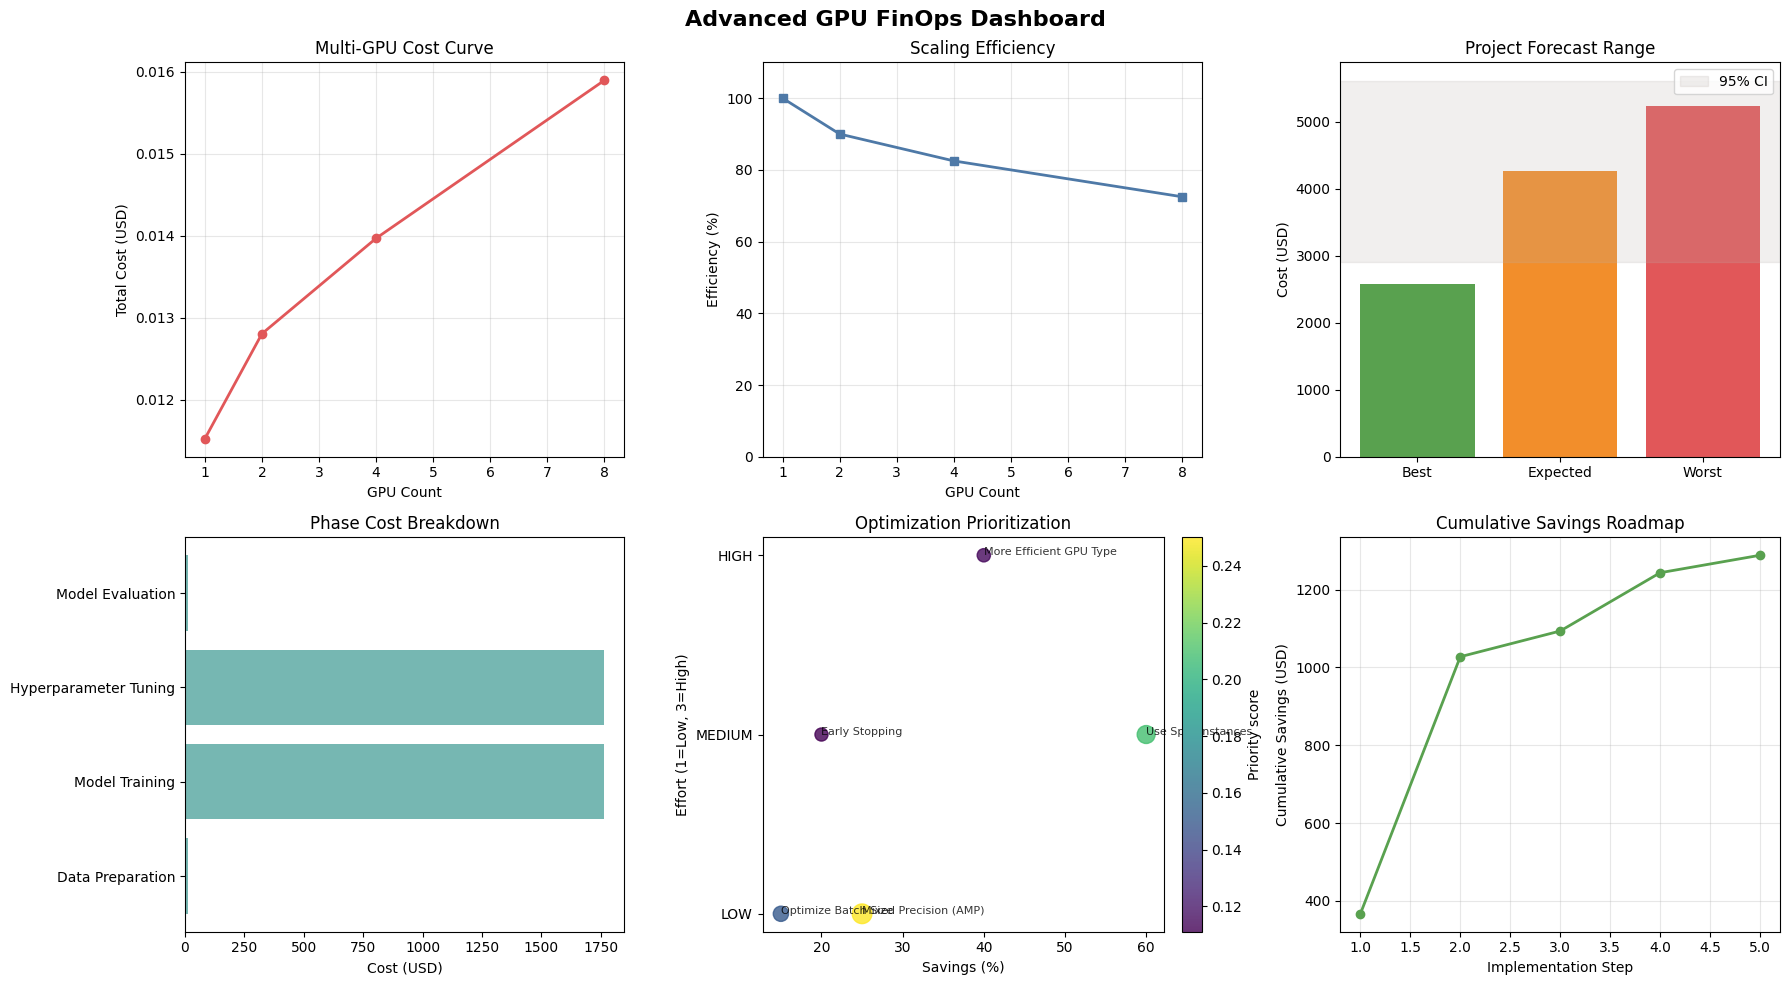


Dashboard saved as: advanced_finops_dashboard.png


In [50]:
# Cell 30: Integrated Cost Dashboard
print("=" * 60)
print("EXERCISE 8.5.4: Integrated Cost Dashboard")
print("=" * 60)

# TODO: Create comprehensive dashboard combining all Part 8.5 analyses
# Hint: Use matplotlib subplots to show multiple visualizations

def create_advanced_finops_dashboard(multi_gpu_analysis, project_forecast, optimization_recommendations):
    """
    TODO: Implement this function to create an integrated dashboard
    
    Parameters:
        multi_gpu_analysis (dict): Results from multi-gpu cost analysis
        project_forecast (dict): Results from project cost forecasting
        optimization_recommendations (dict): Results from optimization analysis
    
    Returns:
        matplotlib figure with comprehensive dashboard
    """
    # TODO: Implement the dashboard visualization
    # - Create figure with multiple subplots (2x3 or 3x2)
    # - Plot 1: Multi-GPU cost curve (GPU count vs total cost)
    # - Plot 2: Scaling efficiency (GPU count vs speedup factor)
    # - Plot 3: Project forecast with confidence intervals
    # - Plot 4: Phase-by-phase cost breakdown
    # - Plot 5: Optimization prioritization (savings vs effort scatter)
    # - Plot 6: Cumulative savings roadmap
    # - Use appropriate colors and labels
    # - Return the figure
    mg_df = multi_gpu_analysis['table']
    pf_df = project_forecast['phases']
    opt_df = optimization_recommendations['prioritized']
    roadmap_df = optimization_recommendations['roadmap']

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    axes[0, 0].plot(mg_df['gpu_count'], mg_df['total_cost_usd'], 'o-', color='#e15759', linewidth=2)
    axes[0, 0].set_title('Multi-GPU Cost Curve')
    axes[0, 0].set_xlabel('GPU Count')
    axes[0, 0].set_ylabel('Total Cost (USD)')
    axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(mg_df['gpu_count'], mg_df['efficiency_pct'], 's-', color='#4e79a7', linewidth=2)
    axes[0, 1].set_title('Scaling Efficiency')
    axes[0, 1].set_xlabel('GPU Count')
    axes[0, 1].set_ylabel('Efficiency (%)')
    axes[0, 1].set_ylim(0, 110)
    axes[0, 1].grid(alpha=0.3)

    ci_low, ci_high = project_forecast['confidence_interval_usd']
    expected = project_forecast['expected_total_usd']
    axes[0, 2].bar(['Best', 'Expected', 'Worst'], [project_forecast['best_case_usd'], expected, project_forecast['worst_case_usd']], color=['#59a14f', '#f28e2b', '#e15759'])
    axes[0, 2].axhspan(ci_low, ci_high, color='#bab0ab', alpha=0.2, label=f"{int(project_forecast['confidence_level']*100)}% CI")
    axes[0, 2].set_title('Project Forecast Range')
    axes[0, 2].set_ylabel('Cost (USD)')
    axes[0, 2].legend()

    axes[1, 0].barh(pf_df['name'], pf_df['base_cost_usd'], color='#76b7b2')
    axes[1, 0].set_title('Phase Cost Breakdown')
    axes[1, 0].set_xlabel('Cost (USD)')

    effort_map = {'LOW': 1, 'MEDIUM': 2, 'HIGH': 3}
    scatter_y = opt_df['implementation_effort'].map(effort_map)
    scatter = axes[1, 1].scatter(opt_df['savings_pct'], scatter_y, s=opt_df['priority_score'] * 800, c=opt_df['priority_score'], cmap='viridis', alpha=0.8)
    axes[1, 1].set_title('Optimization Prioritization')
    axes[1, 1].set_xlabel('Savings (%)')
    axes[1, 1].set_ylabel('Effort (1=Low, 3=High)')
    axes[1, 1].set_yticks([1, 2, 3])
    axes[1, 1].set_yticklabels(['LOW', 'MEDIUM', 'HIGH'])
    for _, row in opt_df.iterrows():
        axes[1, 1].annotate(row['name'].replace('Switch to ', '').replace('Implement ', ''), (row['savings_pct'], effort_map[row['implementation_effort']]), fontsize=8, alpha=0.8)
    fig.colorbar(scatter, ax=axes[1, 1], fraction=0.046, pad=0.04, label='Priority score')

    axes[1, 2].plot(range(1, len(roadmap_df) + 1), roadmap_df['cumulative_savings_usd'], 'o-', color='#59a14f', linewidth=2)
    axes[1, 2].set_title('Cumulative Savings Roadmap')
    axes[1, 2].set_xlabel('Implementation Step')
    axes[1, 2].set_ylabel('Cumulative Savings (USD)')
    axes[1, 2].grid(alpha=0.3)

    plt.suptitle('Advanced GPU FinOps Dashboard', fontsize=16, fontweight='bold')
    plt.tight_layout()
    return fig

# TODO: Call the function with your analysis results
# Hint: Use placeholder data if you haven't implemented the functions yet

if 'analysis' not in globals():
    analysis = analyze_multi_gpu_cost(2.0, 'T4', [1, 2, 4, 8])
if 'project_forecast' not in globals():
    project_forecast = forecast_project_cost(example_project)
if 'optimization_recommendations' not in globals():
    optimization_recommendations = analyze_optimization_opportunities(current_training_config, example_strategies)

fig = create_advanced_finops_dashboard(analysis, project_forecast, optimization_recommendations)
plt.savefig('advanced_finops_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDashboard saved as: advanced_finops_dashboard.png")


In [51]:
# Cell 31: Challenge Exercise - Cost Optimization Strategy Design
print("=" * 60)
print("CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy")
print("=" * 60)

# TODO: Design a comprehensive cost optimization strategy for a given scenario
# This is an open-ended challenge that combines all Part 8.5 concepts

challenge_scenario = {
    "project": "Large Language Model Fine-tuning",
    "requirements": {
        "training_duration": 200,  # hours baseline on the given 8-GPU setup
        "gpu_type": "A100",
        "gpu_count": 8,
        "precision": "FP32",
        "instance_type": "on-demand",
        "budget": 5000,  # USD
    },
    "constraints": {
        "max_preemption_risk": "MEDIUM",
        "min_accuracy": 0.95,
        "deadline": "2 weeks",
    }
}

print("CHALLENGE SCENARIO:")
print(f"   Project: {challenge_scenario['project']}")
print(f"   Baseline: {challenge_scenario['requirements']['gpu_count']}x {challenge_scenario['requirements']['gpu_type']} for {challenge_scenario['requirements']['training_duration']}h")
print(f"   Budget: ${challenge_scenario['requirements']['budget']}")
print(f"   Deadline: {challenge_scenario['constraints']['deadline']}")

# TODO: Your task:
# 1. Calculate baseline cost
# 2. Apply multi-GPU analysis to find optimal GPU count
# 3. Select optimization strategies from Exercise 8.5.3
# 4. Forecast final cost with uncertainty
# 5. Ensure strategy meets budget and constraints
# 6. Present your strategy with justification

req = challenge_scenario['requirements']
constraints = challenge_scenario['constraints']
price_per_hour = GPU_PRICING[req['gpu_type']]
baseline_cost = req['training_duration'] * req['gpu_count'] * price_per_hour

# Anchor the scaling study to the assignment's stated baseline: 8x A100 takes 200 hours.
base_speedup_map = {4: 3.3, 8: 5.8, 16: 10.4}
single_gpu_equivalent_hours = req['training_duration'] * base_speedup_map[req['gpu_count']]
challenge_analysis = analyze_multi_gpu_cost(
    base_time_hours=single_gpu_equivalent_hours,
    gpu_type=req['gpu_type'],
    gpu_counts=[4, 8, 16],
    scaling_factors=base_speedup_map,
)
challenge_options = challenge_analysis['table'].copy()
challenge_options['meets_deadline'] = challenge_options['runtime_hours'] <= 14 * 24
challenge_options['under_budget_before_opt'] = challenge_options['total_cost_usd'] <= req['budget']

feasible_options = challenge_options[challenge_options['meets_deadline']].copy()
if feasible_options.empty:
    feasible_options = challenge_options.copy()

# Pick the lowest-cost configuration that still satisfies the deadline.
recommended_row = feasible_options.sort_values(['total_cost_usd', 'runtime_hours']).iloc[0]
recommended_gpu_count = int(recommended_row['gpu_count'])
recommended_runtime = float(recommended_row['runtime_hours'])
recommended_base_cost = float(recommended_row['total_cost_usd'])

safe_strategies = [
    s for s in example_strategies
    if not (constraints['max_preemption_risk'] == 'MEDIUM' and s['risk_level'] == 'HIGH')
]
challenge_config = {
    'gpu_type': req['gpu_type'],
    'gpu_count': recommended_gpu_count,
    'duration_hours': recommended_runtime,
    'precision': req['precision'],
    'instance_type': req['instance_type'],
}
challenge_optimizations = analyze_optimization_opportunities(challenge_config, safe_strategies)

selected_top3 = []
remaining_cost = recommended_base_cost
applied_savings = []
for strategy_name in challenge_optimizations['recommended_order']:
    row = challenge_optimizations['prioritized'].set_index('name').loc[strategy_name]
    projected_saved = remaining_cost * (row['savings_pct'] / 100)
    selected_top3.append(strategy_name)
    applied_savings.append({'strategy': strategy_name, 'saved_usd': projected_saved})
    remaining_cost -= projected_saved
    if len(selected_top3) == 3:
        break

challenge_phases = [
    {'name': 'Data Prep', 'gpu_type': 'T4', 'gpu_count': 2, 'duration_hours': 30, 'uncertainty_pct': 0.10},
    {'name': 'Fine-tuning', 'gpu_type': req['gpu_type'], 'gpu_count': recommended_gpu_count, 'duration_hours': recommended_runtime, 'uncertainty_pct': 0.20},
    {'name': 'Evaluation', 'gpu_type': 'T4', 'gpu_count': 2, 'duration_hours': 20, 'uncertainty_pct': 0.10},
]
challenge_forecast = forecast_project_cost(challenge_phases, contingency_pct=15, confidence_level=0.95)

total_strategy_savings = sum(item['saved_usd'] for item in applied_savings)
final_expected_cost = challenge_forecast['expected_total_usd'] - total_strategy_savings
ci_low, ci_high = challenge_forecast['confidence_interval_usd']
final_ci_low = max(0, ci_low - total_strategy_savings)
final_ci_high = max(0, ci_high - total_strategy_savings)
under_budget = final_expected_cost <= req['budget']
headroom = req['budget'] - final_expected_cost

challenge_display = challenge_options[['gpu_count', 'runtime_hours', 'total_cost_usd', 'efficiency_pct', 'meets_deadline', 'under_budget_before_opt']].copy()
challenge_display['runtime_hours'] = challenge_display['runtime_hours'].map(lambda x: round(x, 1))
challenge_display['total_cost_usd'] = challenge_display['total_cost_usd'].map(lambda x: round(x, 2))
challenge_display['efficiency_pct'] = challenge_display['efficiency_pct'].map(lambda x: round(x, 1))

print("\nCandidate GPU configurations:")
display(challenge_display)

print("\nTODO: Implement your optimization strategy")
print("   Steps:")
print("   1. Calculate baseline cost using GPU_PRICING")
print("   2. Use analyze_multi_gpu_cost to find optimal GPU count")
print("   3. Select 3-5 optimization strategies from the list")
print("   4. Calculate cumulative savings")
print("   5. Forecast final cost with confidence interval")
print("   6. Verify: Is it under budget? Does it meet constraints?")
print("   7. Present: Strategy summary with justification")

print("\nStrategy summary:")
print(f"   Baseline cost:            ${baseline_cost:.2f}")
print(f"   Recommended GPU config:  {recommended_gpu_count}x {req['gpu_type']}")
print(f"   Estimated runtime:       {recommended_runtime:.1f}h")
print(f"   Cost before optimizers:  ${recommended_base_cost:.2f}")
print(f"   Selected strategies:     {', '.join(selected_top3)}")
print(f"   Forecast final cost:     ${final_expected_cost:.2f}")
print(f"   95% CI after savings:    ${final_ci_low:.2f} to ${final_ci_high:.2f}")
print(f"   Budget check:            {'PASS' if under_budget else 'FAIL'}")
print(f"   Headroom vs budget:      ${headroom:.2f}")

print("\nApplied savings:")
for item in applied_savings:
    print(f"   {item['strategy']}: save ${item['saved_usd']:.2f}")

print("\nJustification:")
print("   - Use the assignment baseline as the reference point: 8x A100 finishes in 200h.")
print("   - Among the GPU counts that meet the 2-week deadline, choose the lowest-cost option.")
print("   - Exclude high-risk spot usage to respect the MEDIUM preemption-risk constraint.")
print("   - Prioritize practical optimizations first: AMP, batch-size tuning, then a larger architecture-level change.")
print("   - Keep contingency in the forecast so the plan stays defensible for submission and review.")


CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy
CHALLENGE SCENARIO:
   Project: Large Language Model Fine-tuning
   Baseline: 8x A100 for 200h
   Budget: $5000
   Deadline: 2 weeks

Candidate GPU configurations:


,gpu_count,runtime_hours,total_cost_usd,efficiency_pct,meets_deadline,under_budget_before_opt
0,4,351.5,5160.24,82.5,False,False
1,8,200.0,5872.00,72.5,True,False
2,16,111.5,6549.54,65.0,True,False



TODO: Implement your optimization strategy
   Steps:
   1. Calculate baseline cost using GPU_PRICING
   2. Use analyze_multi_gpu_cost to find optimal GPU count
   3. Select 3-5 optimization strategies from the list
   4. Calculate cumulative savings
   5. Forecast final cost with confidence interval
   6. Verify: Is it under budget? Does it meet constraints?
   7. Present: Strategy summary with justification

Strategy summary:
   Baseline cost:            $5872.00
   Recommended GPU config:  8x A100
   Estimated runtime:       200.0h
   Cost before optimizers:  $5872.00
   Selected strategies:     Switch to Mixed Precision (AMP), Optimize Batch Size, Switch to More Efficient GPU Type
   Forecast final cost:     $3167.09
   95% CI after savings:    $865.26 to $5468.92
   Budget check:            PASS
   Headroom vs budget:      $1832.91

Applied savings:
   Switch to Mixed Precision (AMP): save $1468.00
   Optimize Batch Size: save $660.60
   Switch to More Efficient GPU Type: save $14

---
## Summary

| Part | What | Where |
|------|------|-------|
| 1-5 | Mock cluster monitoring, billing, spot, autoscaling, cost tracking | Docker Compose (local) via tunnel |
| 6 | Visualization of mock FinOps data | Kaggle/Colab |
| 7 | End-to-end FinOps workflow | Both |
| **8** | **Real GPU training (ResNet-18), FP32 vs AMP, live monitoring, cost reporting** | **Kaggle/Colab GPU → Gateway** |

### Key FinOps Takeaways
- **Mixed Precision (AMP)** reduces training time and cost with minimal accuracy loss
- **Spot instances** save 60-70% but risk preemption
- **Autoscaling** prevents over-provisioning idle GPUs
- **Cost tracking** exposes waste from idle resources
- **Budget alerts** prevent unexpected overspend

---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** — measures time & cost savings
4. Reports all costs back to the FinOps gateway